# Data Book Keeping

In [17]:
import sys
sys.path.insert(0, '../../src_tf/')

import numpy as np

import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from math import ceil
from quantum_tools import reshuffle

from spectrum import channel_spectrum
from utils import loader, saver


#np.set_printoptions(threshold=sys.maxsize)
np.set_printoptions(precision=4)

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

path1 = "../experiments/data/"
path2 = "data/"

## Four Qubits

In [3]:
n = 4
d = 2**n

[model1, model2, model3, model4, model5] = loader(path1 + "belem_4qubit_repeated.model")

spectrum1 = channel_spectrum(model1.channel, keep_unity=False)
spectrum2 = channel_spectrum(model2.channel, keep_unity=False) 
spectrum3 = channel_spectrum(model3.channel, keep_unity=False)
spectrum4 = channel_spectrum(model4.channel, keep_unity=False)
spectrum5 = channel_spectrum(model5.channel, keep_unity=False)


[distance1, diluted1] = loader(path2 + "diluted_fitting_KL_4qubit_8layer.model")

[distance2, diluted2] = loader(path2 + "diluted_fitting_KL_4qubit_16layer.model")

[distance3, diluted3] = loader(path2 + "diluted_fitting_KL_4qubit_24layer.model")

[distance4, diluted4] = loader(path2 + "diluted_fitting_KL_4qubit_32layer.model")

[distance5, diluted5] = loader(path2 + "diluted_fitting_KL_4qubit_40layer.model")

layers_list = [8, 16, 24, 32, 40]

rank_list = []
rank_list.append(diluted1.channel.rank)
rank_list.append(diluted2.channel.rank)
rank_list.append(diluted3.channel.rank)
rank_list.append(diluted4.channel.rank)
rank_list.append(diluted5.channel.rank)

p_list = []
p_list.append(1- diluted1.channel.c)
p_list.append(1- diluted2.channel.c)
p_list.append(1- diluted3.channel.c)
p_list.append(1- diluted4.channel.c)
p_list.append(1- diluted5.channel.c)

#save the data to a txt, with header "layers, rank, p"
with open(path2 + "diluted_fitting_KL_4qubit.txt", "w") as f:
    f.write("layers, rank, p\n")
    for i in range(len(layers_list)):
        f.write("{}, {}, {}\n".format(layers_list[i], rank_list[i], p_list[i]))

#save the spectral eigenvalues to a txt
with open(path2 + "variational_spectrum_8layers.txt", "w") as f:
    for eig in spectrum1:
        f.write("{}, {}\n".format(np.real(eig[0]), np.real(eig[1])))

with open(path2 + "variational_spectrum_16layers.txt", "w") as f:
    for eig in spectrum2:
        f.write("{}, {}\n".format(np.real(eig[0]), np.real(eig[1])))

with open(path2 + "variational_spectrum_24layers.txt", "w") as f:
    for eig in spectrum3:
        f.write("{}, {}\n".format(np.real(eig[0]), np.real(eig[1])))

with open(path2 + "variational_spectrum_32layers.txt", "w") as f:
    for eig in spectrum4:
        f.write("{}, {}\n".format(np.real(eig[0]), np.real(eig[1])))

with open(path2 + "variational_spectrum_40layers.txt", "w") as f:
    for eig in spectrum5:
        f.write("{}, {}\n".format(np.real(eig[0]), np.real(eig[1])))

## Three Qubits

In [20]:
model_list = loader(path1 + "belem_3qubit_repeated.model")

In [25]:
for i, model in enumerate(model_list[0]):
    SO = reshuffle(model.channel.choi)
    saver(SO, f"book_keeping/superoperators_3q/layers8/superoperator{i}")

In [26]:
for i, model in enumerate(model_list[1]):
    SO = reshuffle(model.channel.choi)
    saver(SO, f"book_keeping/superoperators_3q/layers16/superoperator{i}")

In [27]:
for i, model in enumerate(model_list[2]):
    SO = reshuffle(model.channel.choi)
    saver(SO, f"book_keeping/superoperators_3q/layers24/superoperator{i}")

In [28]:
for i, model in enumerate(model_list[3]):
    SO = reshuffle(model.channel.choi)
    saver(SO, f"book_keeping/superoperators_3q/layers32/superoperator{i}")

In [29]:
for i, model in enumerate(model_list[4]):
    SO = reshuffle(model.channel.choi)
    saver(SO, f"book_keeping/superoperators_3q/layers40/superoperator{i}")

In [31]:
eig,_ = np.linalg.eig(SO)

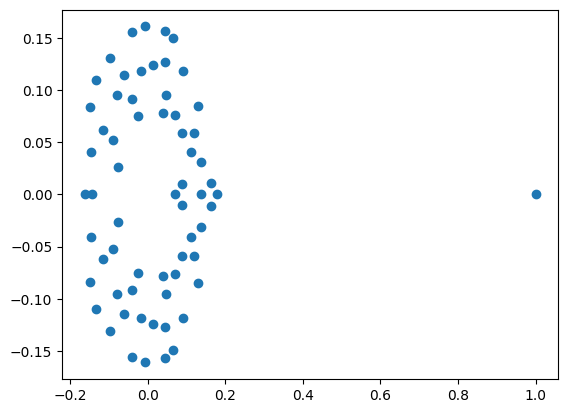

In [34]:
plt.plot(eig.real, eig.imag, "o")